# Phase II: Cyanobacteria Abundance Forecasting

*Course project of **STATS 402: Interdisciplinary Data Analysis**.*

**Name:** Ziyue Yin

**NetID:** zy166

**How to use this Notebook *wisely*?**

## Prerequisites

Before we continue, please make sure that the following files exist in the corresponding path:
- ILW：`/dkucc/home/zy166/HAB-forecasting/datasets/processed/lake_ci_daily.parquet`
- Daymet：`/dkucc/home/zy166/HAB-forecasting/datasets/Daymet/daymet_glakes_daily.parquet`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 120

ROOT = Path("/dkucc/home/zy166/HAB-forecasting")
P_ILW    = ROOT / "datasets/processed/lake_ci_daily.parquet"
P_DAYMET = ROOT / "datasets/Daymet/daymet_glakes_daily.parquet"

print(P_ILW)
print(P_DAYMET)

/dkucc/home/zy166/HAB-forecasting/datasets/processed/lake_ci_daily.parquet
/dkucc/home/zy166/HAB-forecasting/datasets/Daymet/daymet_glakes_daily.parquet


Now, we read and merge the preprocessed ILW and Daymet data.

In [2]:
# 读取
df_ilw = pd.read_parquet(P_ILW)
df_daymet = pd.read_parquet(P_DAYMET)

# 统一日期：去掉时区，只保留日期（当天 00:00）
df_ilw["date"] = pd.to_datetime(df_ilw["date"]).dt.tz_localize(None).dt.normalize()
df_daymet["date"] = pd.to_datetime(df_daymet["date"]).dt.tz_localize(None).dt.normalize()

print("ILW columns:", df_ilw.columns.tolist())
print("Daymet columns:", df_daymet.columns.tolist())
display(df_ilw.head())
display(df_daymet.head())

ILW columns: ['lake_id', 'date', 'product', 'CI_mean', 'CI_p90', 'n_valid', 'src', 'engine']
Daymet columns: ['lake_id', 'lake_name', 'date', 'tmin', 'tmax', 'prcp', 'srad', 'vp', 'dayl']


,lake_id,date,product,CI_mean,CI_p90,n_valid,src,engine
0,GL-1,2024-01-01,daily,0.000050,0.00005,4140,S3M_OLCI_EFRNT.20240101.L3m.DAY.ILW_CONUS.V5.a...,netcdf4
1,GL-1,2024-01-02,daily,0.000052,0.00005,763,S3M_OLCI_EFRNT.20240102.L3m.DAY.ILW_CONUS.V5.a...,netcdf4
2,GL-1,2024-01-03,daily,NaN,NaN,0,S3M_OLCI_EFRNT.20240103.L3m.DAY.ILW_CONUS.V5.a...,netcdf4
3,GL-1,2024-01-04,daily,0.000052,0.00005,24332,S3M_OLCI_EFRNT.20240104.L3m.DAY.ILW_CONUS.V5.a...,netcdf4
4,GL-1,2024-01-05,daily,0.000095,0.00005,887,S3M_OLCI_EFRNT.20240105.L3m.DAY.ILW_CONUS.V5.a...,netcdf4


,lake_id,lake_name,date,tmin,tmax,prcp,srad,vp,dayl
0,GL-1,Erie,2024-01-01,-0.203859,2.958577,0.365888,102.113113,602.591919,32349.982422
1,GL-1,Erie,2024-01-02,-0.614141,2.104940,0.032669,89.671196,584.490723,32394.982422
2,GL-1,Erie,2024-01-03,0.070455,2.292327,1.025123,72.518929,613.914124,32443.656250
3,GL-1,Erie,2024-01-04,-3.859408,0.760503,0.000000,146.215637,460.223694,32495.972656
4,GL-1,Erie,2024-01-05,-4.978480,0.059113,0.000000,156.474442,422.685303,32551.880859


In [3]:
# 只保留 daily & 有效像元
df_ilw = df_ilw.copy()
df_ilw = df_ilw[df_ilw["n_valid"].fillna(0) > 0]
if "product" in df_ilw.columns:
    df_ilw = df_ilw[df_ilw["product"] == "daily"]

# 合并 lake_id × date
df = (
    df_ilw.merge(
        df_daymet,
        on=["lake_id", "date"],
        how="inner",
        suffixes=("_ilw", "_daymet"),
    )
)

print("Merged shape:", df.shape)
display(df.head())

Merged shape: (1698, 15)


,lake_id,date,product,CI_mean,CI_p90,n_valid,src,engine,lake_name,tmin,tmax,prcp,srad,vp,dayl
0,GL-1,2024-01-01,daily,0.000050,0.00005,4140,S3M_OLCI_EFRNT.20240101.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-0.203859,2.958577,0.365888,102.113113,602.591919,32349.982422
1,GL-1,2024-01-02,daily,0.000052,0.00005,763,S3M_OLCI_EFRNT.20240102.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-0.614141,2.104940,0.032669,89.671196,584.490723,32394.982422
2,GL-1,2024-01-04,daily,0.000052,0.00005,24332,S3M_OLCI_EFRNT.20240104.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-3.859408,0.760503,0.000000,146.215637,460.223694,32495.972656
3,GL-1,2024-01-05,daily,0.000095,0.00005,887,S3M_OLCI_EFRNT.20240105.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-4.978480,0.059113,0.000000,156.474442,422.685303,32551.880859
4,GL-1,2024-01-06,daily,0.000050,0.00005,7,S3M_OLCI_EFRNT.20240106.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-3.090726,2.353635,2.988052,148.110809,486.841797,32611.357422


Basic characteristics (seasonality)

In [4]:
df = df.copy()
df["doy"] = df["date"].dt.dayofyear
df["sin_doy"] = np.sin(2 * np.pi * df["doy"] / 365.25)
df["cos_doy"] = np.cos(2 * np.pi * df["doy"] / 365.25)

daymet_vars = ["tmin", "tmax", "prcp", "srad", "vp", "dayl"]
daymet_vars = [v for v in daymet_vars if v in df.columns]
print("Daymet vars:", daymet_vars)

TARGET_RAW = "CI_p90"   # or `CI_mean`

Daymet vars: ['tmin', 'tmax', 'prcp', 'srad', 'vp', 'dayl']


Construct temporal features (lags rolling)

Here, only the past information is used to construct features:
- ILW：lag1 / lag7 / 7日 & 28日滚动均值（用到 t-1 及更早的值）
- Daymet：7/28 日滚动均值（包含当天）

In [5]:
df_ts = df.sort_values(["lake_id", "date"]).copy()

# 1. ILW 自身的滞后和滚动
lags_ci = [1, 7]
roll_windows_ci = [7, 28]

for lag in lags_ci:
    df_ts[f"{TARGET_RAW}_lag{lag}"] = (
        df_ts.groupby("lake_id")[TARGET_RAW].shift(lag)
    )

for w in roll_windows_ci:
    # 每个湖内部：先 shift(1) 再 rolling，确保只用到过去的值
    df_ts[f"{TARGET_RAW}_roll{w}"] = (
        df_ts.groupby("lake_id")[TARGET_RAW]
             .apply(lambda s: s.shift(1).rolling(window=w, min_periods=max(3, w//4)).mean())
             .reset_index(level=0, drop=True)
    )

# 2. Daymet 的 7/28 日滚动均值（包含当天）
roll_windows_met = [7, 28]

for var in daymet_vars:
    for w in roll_windows_met:
        df_ts[f"{var}_roll{w}"] = (
            df_ts.groupby("lake_id")[var]
                 .rolling(window=w, min_periods=max(3, w//4))
                 .mean()
                 .reset_index(level=0, drop=True)
        )

print("Columns after feature engineering:")
print(df_ts.columns.tolist())
display(df_ts.head())

Columns after feature engineering:
['lake_id', 'date', 'product', 'CI_mean', 'CI_p90', 'n_valid', 'src', 'engine', 'lake_name', 'tmin', 'tmax', 'prcp', 'srad', 'vp', 'dayl', 'doy', 'sin_doy', 'cos_doy', 'CI_p90_lag1', 'CI_p90_lag7', 'CI_p90_roll7', 'CI_p90_roll28', 'tmin_roll7', 'tmin_roll28', 'tmax_roll7', 'tmax_roll28', 'prcp_roll7', 'prcp_roll28', 'srad_roll7', 'srad_roll28', 'vp_roll7', 'vp_roll28', 'dayl_roll7', 'dayl_roll28']


,lake_id,date,product,CI_mean,CI_p90,n_valid,src,engine,lake_name,tmin,...,tmax_roll7,tmax_roll28,prcp_roll7,prcp_roll28,srad_roll7,srad_roll28,vp_roll7,vp_roll28,dayl_roll7,dayl_roll28
0,GL-1,2024-01-01,daily,0.000050,0.00005,4140,S3M_OLCI_EFRNT.20240101.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-0.203859,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GL-1,2024-01-02,daily,0.000052,0.00005,763,S3M_OLCI_EFRNT.20240102.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-0.614141,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GL-1,2024-01-04,daily,0.000052,0.00005,24332,S3M_OLCI_EFRNT.20240104.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-3.859408,...,1.941340,NaN,0.132852,NaN,112.666649,NaN,549.102112,NaN,32413.645833,NaN
3,GL-1,2024-01-05,daily,0.000095,0.00005,887,S3M_OLCI_EFRNT.20240105.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-4.978480,...,1.470783,NaN,0.099639,NaN,123.618597,NaN,517.497910,NaN,32448.204590,NaN
4,GL-1,2024-01-06,daily,0.000050,0.00005,7,S3M_OLCI_EFRNT.20240106.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-3.090726,...,1.647354,NaN,0.677322,NaN,128.517039,NaN,511.366687,NaN,32480.835156,NaN


定义 target & feature 列，删掉 NaN

In [6]:
# 用 log1p 缓解偏态
df_ts["target"] = np.log1p(df_ts[TARGET_RAW])

# 列出所有候选特征列（排除这些非特征）
non_feature_cols = {
    "lake_id", "lake_name", "date", "product", "src", "engine",
    "n_valid", "doy", TARGET_RAW, "target"
}
feature_cols = [c for c in df_ts.columns if c not in non_feature_cols]

print("Number of features:", len(feature_cols))
print("First few features:", feature_cols[:10])

# 丢掉含 NaN 的行（多半是最开始几天没有足够历史）
df_feat = df_ts.dropna(subset=feature_cols + ["target"]).copy()
df_feat = df_feat.sort_values(["lake_id", "date"])

print("After dropping NaNs:", df_feat.shape)
display(df_feat.head())

Number of features: 25
First few features: ['CI_mean', 'tmin', 'tmax', 'prcp', 'srad', 'vp', 'dayl', 'sin_doy', 'cos_doy', 'CI_p90_lag1']
After dropping NaNs: (1663, 35)


,lake_id,date,product,CI_mean,CI_p90,n_valid,src,engine,lake_name,tmin,...,tmax_roll28,prcp_roll7,prcp_roll28,srad_roll7,srad_roll28,vp_roll7,vp_roll28,dayl_roll7,dayl_roll28,target
7,GL-1,2024-01-11,daily,0.000050,0.000050,162,S3M_OLCI_EFRNT.20240111.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,0.520005,...,2.713870,1.505975,1.363464,126.479536,123.433733,550.805246,557.278580,32662.774275,32623.675293,0.000050
8,GL-1,2024-01-12,daily,0.002157,0.002157,2,S3M_OLCI_EFRNT.20240112.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-1.014221,...,3.137238,3.193206,2.527888,136.115728,127.177156,548.385899,558.420437,32754.969308,32669.972222,0.002155
9,GL-1,2024-01-13,daily,0.000050,0.000050,2,S3M_OLCI_EFRNT.20240113.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-4.143497,...,3.383074,3.560877,2.532470,144.477575,134.934297,547.093624,547.696170,32844.602679,32715.315625,0.000050
10,GL-1,2024-01-14,daily,0.000074,0.000055,10226,S3M_OLCI_EFRNT.20240114.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-13.189394,...,2.632886,3.612439,2.335058,154.665337,143.375613,518.703899,518.265357,32938.565569,32760.252486,0.000055
11,GL-1,2024-01-15,daily,0.000059,0.000050,14356,S3M_OLCI_EFRNT.20240115.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-15.542664,...,1.693052,3.308811,2.212357,166.332122,150.575837,475.295353,490.325076,33036.792969,32805.143880,0.000050


Several utility functions

In [7]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def train_eval_rf(X_train, y_train, X_test, y_test, random_state=42):
    model = RandomForestRegressor(
        n_estimators=400,
        random_state=random_state,
        n_jobs=-1,
        min_samples_leaf=3,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return model, y_pred, r2_score(y_test, y_pred), rmse(y_test, y_pred)

def plot_ts_true_pred(df_lake, dates, y_true, y_pred, title=""):
    plt.figure(figsize=(8, 3.5))
    plt.plot(dates, y_true, label="True (log1p CI)")
    plt.plot(dates, y_pred, label="Predicted", linestyle="--")
    plt.xticks(rotation=45)
    plt.ylabel("log1p CI")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 单湖模型：同一湖的时间预测（time-based split）

思路：每个湖按日期排序，用前 70% 作为训练、后 30% 作为测试，评估 RF 相对于 “训练集均值基线” 的提升。

逐湖时间切分 & 评估

In [8]:
results_time_lake = []

train_frac = 0.7
min_train = 80   # 每个湖至少多少 train 样本
min_test  = 30   # 每个湖至少多少 test 样本

for lake_id, df_lake in df_feat.groupby("lake_id"):
    df_lake = df_lake.sort_values("date").reset_index(drop=True)
    n = len(df_lake)
    if n < (min_train + min_test):
        print(f"[SKIP] {lake_id}: too few samples ({n})")
        continue

    n_train = int(n * train_frac)
    if n_train < min_train or (n - n_train) < min_test:
        print(f"[SKIP] {lake_id}: not enough train/test after split ({n_train}/{n-n_train})")
        continue

    # 切分
    train = df_lake.iloc[:n_train]
    test  = df_lake.iloc[n_train:]

    X_train = train[feature_cols].values
    y_train = train["target"].values
    X_test  = test[feature_cols].values
    y_test  = test["target"].values

    # baseline：用训练集平均值作常数预测
    baseline_pred = np.repeat(y_train.mean(), len(y_test))
    r2_base = r2_score(y_test, baseline_pred)
    rmse_base = rmse(y_test, baseline_pred)

    # RF 模型
    model, y_pred, r2_rf, rmse_rf = train_eval_rf(X_train, y_train, X_test, y_test)

    lake_name = df_lake.get("lake_name", pd.Series([lake_id])).iloc[0]
    results_time_lake.append({
        "lake_id": lake_id,
        "lake_name": lake_name,
        "n_total": n,
        "n_train": n_train,
        "n_test": n - n_train,
        "r2_baseline": r2_base,
        "rmse_baseline": rmse_base,
        "r2_rf": r2_rf,
        "rmse_rf": rmse_rf,
    })

    print(f"[TIME] {lake_id} ({lake_name}): "
          f"R2_base={r2_base:.3f}, R2_RF={r2_rf:.3f}, "
          f"RMSE_base={rmse_base:.3f}, RMSE_RF={rmse_rf:.3f}, n={n}")

results_time_lake = pd.DataFrame(results_time_lake)
display(results_time_lake)

[TIME] GL-1 (Erie): R2_base=-0.010, R2_RF=0.613, RMSE_base=0.002, RMSE_RF=0.001, n=328
[TIME] GL-2 (Huron): R2_base=-0.000, R2_RF=0.917, RMSE_base=0.000, RMSE_RF=0.000, n=335
[TIME] GL-3 (Michigan): R2_base=-0.020, R2_RF=-0.020, RMSE_base=0.001, RMSE_RF=0.001, n=338
[TIME] GL-4 (Ontario): R2_base=-0.001, R2_RF=0.840, RMSE_base=0.000, RMSE_RF=0.000, n=318
[TIME] GL-5 (Superior): R2_base=-0.530, R2_RF=-120.646, RMSE_base=0.000, RMSE_RF=0.000, n=344


,lake_id,lake_name,n_total,n_train,n_test,r2_baseline,rmse_baseline,r2_rf,rmse_rf
0,GL-1,Erie,328,229,99,-0.009994,0.001503,0.612770,0.000931
1,GL-2,Huron,335,234,101,-0.000021,0.000288,0.917080,0.000083
2,GL-3,Michigan,338,236,102,-0.020229,0.000622,-0.020229,0.000622
3,GL-4,Ontario,318,222,96,-0.000520,0.000281,0.839693,0.000112
4,GL-5,Superior,344,240,104,-0.530095,0.000017,-120.646374,0.000156


随便挑一个湖画 time series 对比

Example lake: GL-2


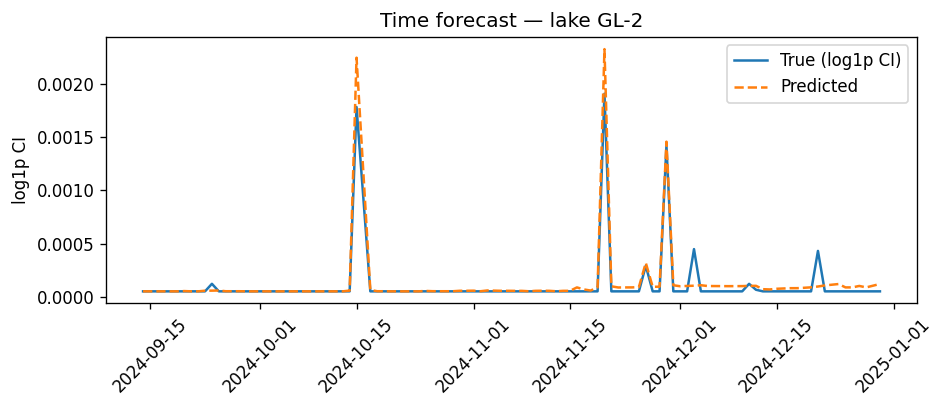

In [9]:
if not results_time_lake.empty:
    # 选一个湖（比如 RF 的 R2 最大的那个）
    best_lake_id = results_time_lake.sort_values("r2_rf", ascending=False)["lake_id"].iloc[0]
    print("Example lake:", best_lake_id)

    df_lake = df_feat[df_feat["lake_id"] == best_lake_id].sort_values("date").reset_index(drop=True)
    n = len(df_lake)
    n_train = int(n * train_frac)

    train = df_lake.iloc[:n_train]
    test  = df_lake.iloc[n_train:]

    X_train = train[feature_cols].values
    y_train = train["target"].values
    X_test  = test[feature_cols].values
    y_test  = test["target"].values

    model, y_pred, r2_rf, rmse_rf = train_eval_rf(X_train, y_train, X_test, y_test)

    plot_ts_true_pred(
        df_lake,
        dates=test["date"].values,
        y_true=y_test,
        y_pred=y_pred,
        title=f"Time forecast — lake {best_lake_id}"
    )

## 湖之间的泛化（5-fold，leave-one-lake-out）

这里我们做「按湖分折」的 cross-validation：每次留出一个湖的全部样本做 test，其余 4 个湖的全部样本做 train。

由于特征都是用本湖过去信息构造的，这样不会造成“时间穿越”。

5-fold LOLO CV

In [10]:
unique_lakes = sorted(df_feat["lake_id"].unique())
print("Lakes:", unique_lakes)

results_lake_lofo = []

# 用于整体汇总
all_y_true = []
all_y_pred = []

for holdout in unique_lakes:
    df_train = df_feat[df_feat["lake_id"] != holdout]
    df_test  = df_feat[df_feat["lake_id"] == holdout]

    if len(df_test) < 30 or len(df_train) < 100:
        print(f"[SKIP LOLO] holdout={holdout}, train={len(df_train)}, test={len(df_test)}")
        continue

    X_train = df_train[feature_cols].values
    y_train = df_train["target"].values
    X_test  = df_test[feature_cols].values
    y_test  = df_test["target"].values

    # baseline：用训练集整体均值
    baseline_pred = np.repeat(y_train.mean(), len(y_test))
    r2_base = r2_score(y_test, baseline_pred)
    rmse_base = rmse(y_test, baseline_pred)

    # RF
    model, y_pred, r2_rf, rmse_rf = train_eval_rf(X_train, y_train, X_test, y_test)

    lake_name = df_test.get("lake_name", pd.Series([holdout])).iloc[0]
    results_lake_lofo.append({
        "holdout_lake_id": holdout,
        "holdout_lake_name": lake_name,
        "n_train": len(df_train),
        "n_test": len(df_test),
        "r2_baseline": r2_base,
        "rmse_baseline": rmse_base,
        "r2_rf": r2_rf,
        "rmse_rf": rmse_rf,
    })

    all_y_true.append(y_test)
    all_y_pred.append(y_pred)

    print(f"[LOLO] holdout={holdout} ({lake_name}): "
          f"R2_base={r2_base:.3f}, R2_RF={r2_rf:.3f}, "
          f"RMSE_base={rmse_base:.3f}, RMSE_RF={rmse_rf:.3f}, "
          f"train={len(df_train)}, test={len(df_test)}")

results_lake_lofo = pd.DataFrame(results_lake_lofo)
display(results_lake_lofo)

Lakes: ['GL-1', 'GL-2', 'GL-3', 'GL-4', 'GL-5']
[LOLO] holdout=GL-1 (Erie): R2_base=-0.046, R2_RF=0.466, RMSE_base=0.001, RMSE_RF=0.001, train=1335, test=328
[LOLO] holdout=GL-2 (Huron): R2_base=-0.013, R2_RF=0.923, RMSE_base=0.000, RMSE_RF=0.000, train=1328, test=335
[LOLO] holdout=GL-3 (Michigan): R2_base=-0.062, R2_RF=0.727, RMSE_base=0.000, RMSE_RF=0.000, train=1325, test=338
[LOLO] holdout=GL-4 (Ontario): R2_base=-0.044, R2_RF=0.727, RMSE_base=0.000, RMSE_RF=0.000, train=1345, test=318
[LOLO] holdout=GL-5 (Superior): R2_base=-0.475, R2_RF=0.951, RMSE_base=0.000, RMSE_RF=0.000, train=1319, test=344


,holdout_lake_id,holdout_lake_name,n_train,n_test,r2_baseline,rmse_baseline,r2_rf,rmse_rf
0,GL-1,Erie,1335,328,-0.045569,0.001459,0.465558,0.001043
1,GL-2,Huron,1328,335,-0.012689,0.000379,0.922871,0.000105
2,GL-3,Michigan,1325,338,-0.061678,0.000351,0.726668,0.000178
3,GL-4,Ontario,1345,318,-0.043566,0.000321,0.726620,0.000164
4,GL-5,Superior,1319,344,-0.475310,0.000189,0.951059,0.000034


整体 LOLO 表现（所有测试湖拼在一起）

In [11]:
if all_y_true:
    y_true_all = np.concatenate(all_y_true)
    y_pred_all = np.concatenate(all_y_pred)

    r2_all = r2_score(y_true_all, y_pred_all)
    rmse_all = rmse(y_true_all, y_pred_all)

    print(f"[LOLO OVERALL] R2={r2_all:.3f}, RMSE={rmse_all:.3f}")

[LOLO OVERALL] R2=0.536, RMSE=0.000
